# Objectif du notebook 

Date de création : 03/06/2026

Extraction de signaux reçu pour analyse par time-warping selon le tutoriel de J.Bonnel 

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.io.wavfile as wavfile

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
# from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


# from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
#     # ActiveFiberscopeManager,
#     # PassiveFiberscopeManager,
#     BandFilter,
# )

from source.rtf_mfp.rtf_mfp_plot_utils import plot_sequence_spectrogram
from misc import BandFilter
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
# from misc import progression_bar
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import (
    plot_seq_replica_positions,
)

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# # Select only pulses emitted between OBS1 and OBS3
pulse_slice = (0, 40)     # Only between OBS1 and OBS3
df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [6]:
print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")


Signal properties for sequence 144:
	Number of pulses: 41
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds


# Étape 2 : calcul du vecteur de RTFs
Le vecteur de RTF est estimé pour chaque position de la source à l'aide de la méthode CS-EVD et par déconvolution. 

## Définition des paramètres du processeur

In [7]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study
    "tau_rtf_analysis": 8.1,
    "alpha_overlap": 0.95,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

## Calcul des RTFs

In [8]:
###########################
# Library
###########################
id_library = 150

active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# rtf_mfp_processor.compute_library(
#     active_feature_args=active_replicas_args,
#     passive_feature_args=passive_replicas_args,
#     id=id_library,
# )

## Chargement des données 

In [9]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_150.nc"
ds = xr.open_dataset(fpath)
ds

<xarray.Dataset> Size: 15MB
Dimensions:           (h_index: 3, f_rtf: 8193, replica_id: 41, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int64 24B 1 2 3
  * f_rtf             (f_rtf) float32 33kB 0.0 0.1221 0.2441 ... 999.9 1e+03
  * replica_id        (replica_id) int64 328B 0 1 2 3 4 5 ... 35 36 37 38 39 40
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 4MB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 4MB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 3MB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 3MB ...
    feature_psd       (f_rtf, replica_id) float32 1MB ...
    e_replica         (replica_id) float32 164B ...
    n_replica         (replica_id) float32 164B ...
    u_replica         (replica_id) float32 164B ...
    replica_type      (replica_id) int64 328B ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     150

In [10]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_144_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 59MB
Dimensions:                     (h_index: 3, time: 672123, pulse_id: 41,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 8193,
                                 f_csdm: 8193, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int64 24B 1 2 3
  * time                        (time) float32 3MB 0.0 0.0005 ... 336.1 336.1
  * pulse_id                    (pulse_id) int64 328B 0 1 2 3 4 ... 37 38 39 40
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * f_csdm                      (f_csdm) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * h_index_bis                 (h_index_bis) int64 24B 1 2 3
Data variables:
    signal                      (h_index, time) float32 8MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 492B ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 5MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 3MB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 3MB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 4MB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 4MB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 12MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 12MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 3MB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 3MB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        6.1754999999999995
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_10-51-05
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     10.04

## Illustration de la donnée d'entrée 

### Position de la source le long de la trajectoire 

In [11]:
e1 = ds_gps.attrs[f"obs1_e_apriori"]
n1 = ds_gps.attrs[f"obs1_n_apriori"]
e2 = ds_gps.attrs[f"obs2_e_apriori"]
n2 = ds_gps.attrs[f"obs2_n_apriori"]
e3 = ds_gps.attrs[f"obs3_e_apriori"]
n3 = ds_gps.attrs[f"obs3_n_apriori"]

d_12 = np.sqrt((e2 - e1)**2 + (n2 - n1)**2)
d_13 = np.sqrt((e3 - e1) ** 2 + (n3 - n1) ** 2)
d_23 = np.sqrt((e2 - e3) ** 2 + (n2 - n3) ** 2)

print(f"Distance OBS 1 - OBS 2 : d_12 = {d_12:.2f} m")
print(f"Distance OBS 1 - OBS 3 : d_13 = {d_13:.2f} m")
print(f"Distance OBS 2 - OBS 3 : d_23 = {d_23:.2f} m")

Distance OBS 1 - OBS 2 : d_12 = 899.54 m
Distance OBS 1 - OBS 3 : d_13 = 1844.66 m
Distance OBS 2 - OBS 3 : d_23 = 947.85 m


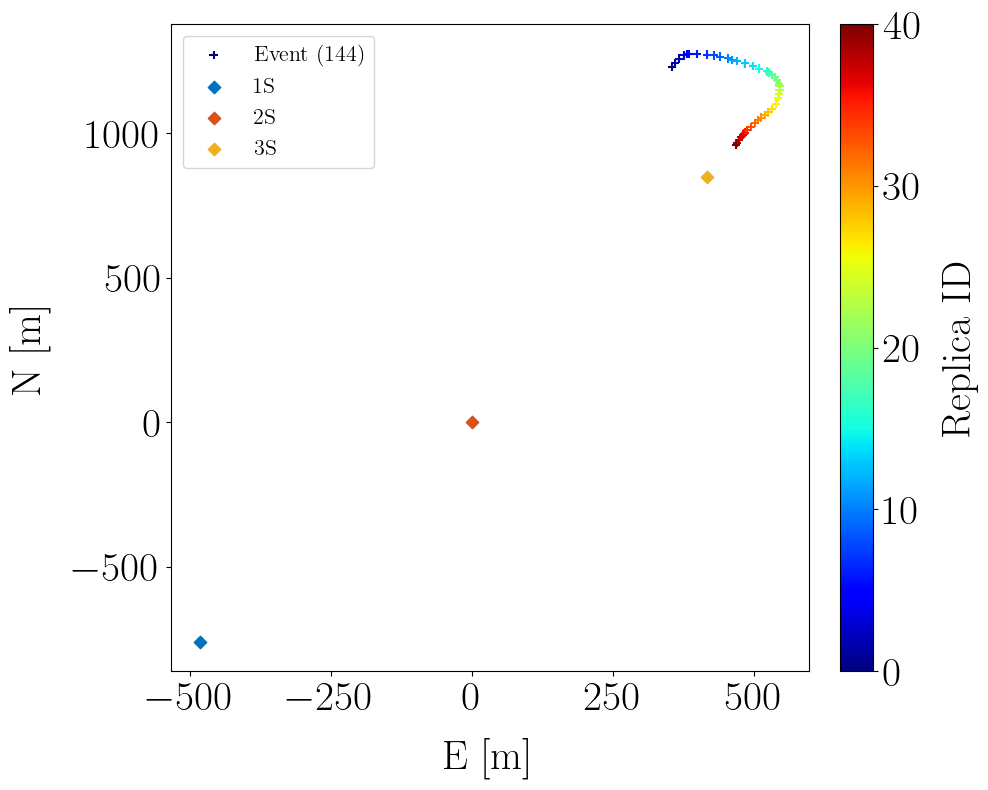

In [12]:
plot_seq_replica_positions(df_seq, ds_gps, root_fig=None)

### Données des OBS 

c:\Users\baptiste.menetrier\Desktop\devPy\phd\source\rtf_mfp\rtf_mfp_plot_utils.py:139: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  fig.canvas.

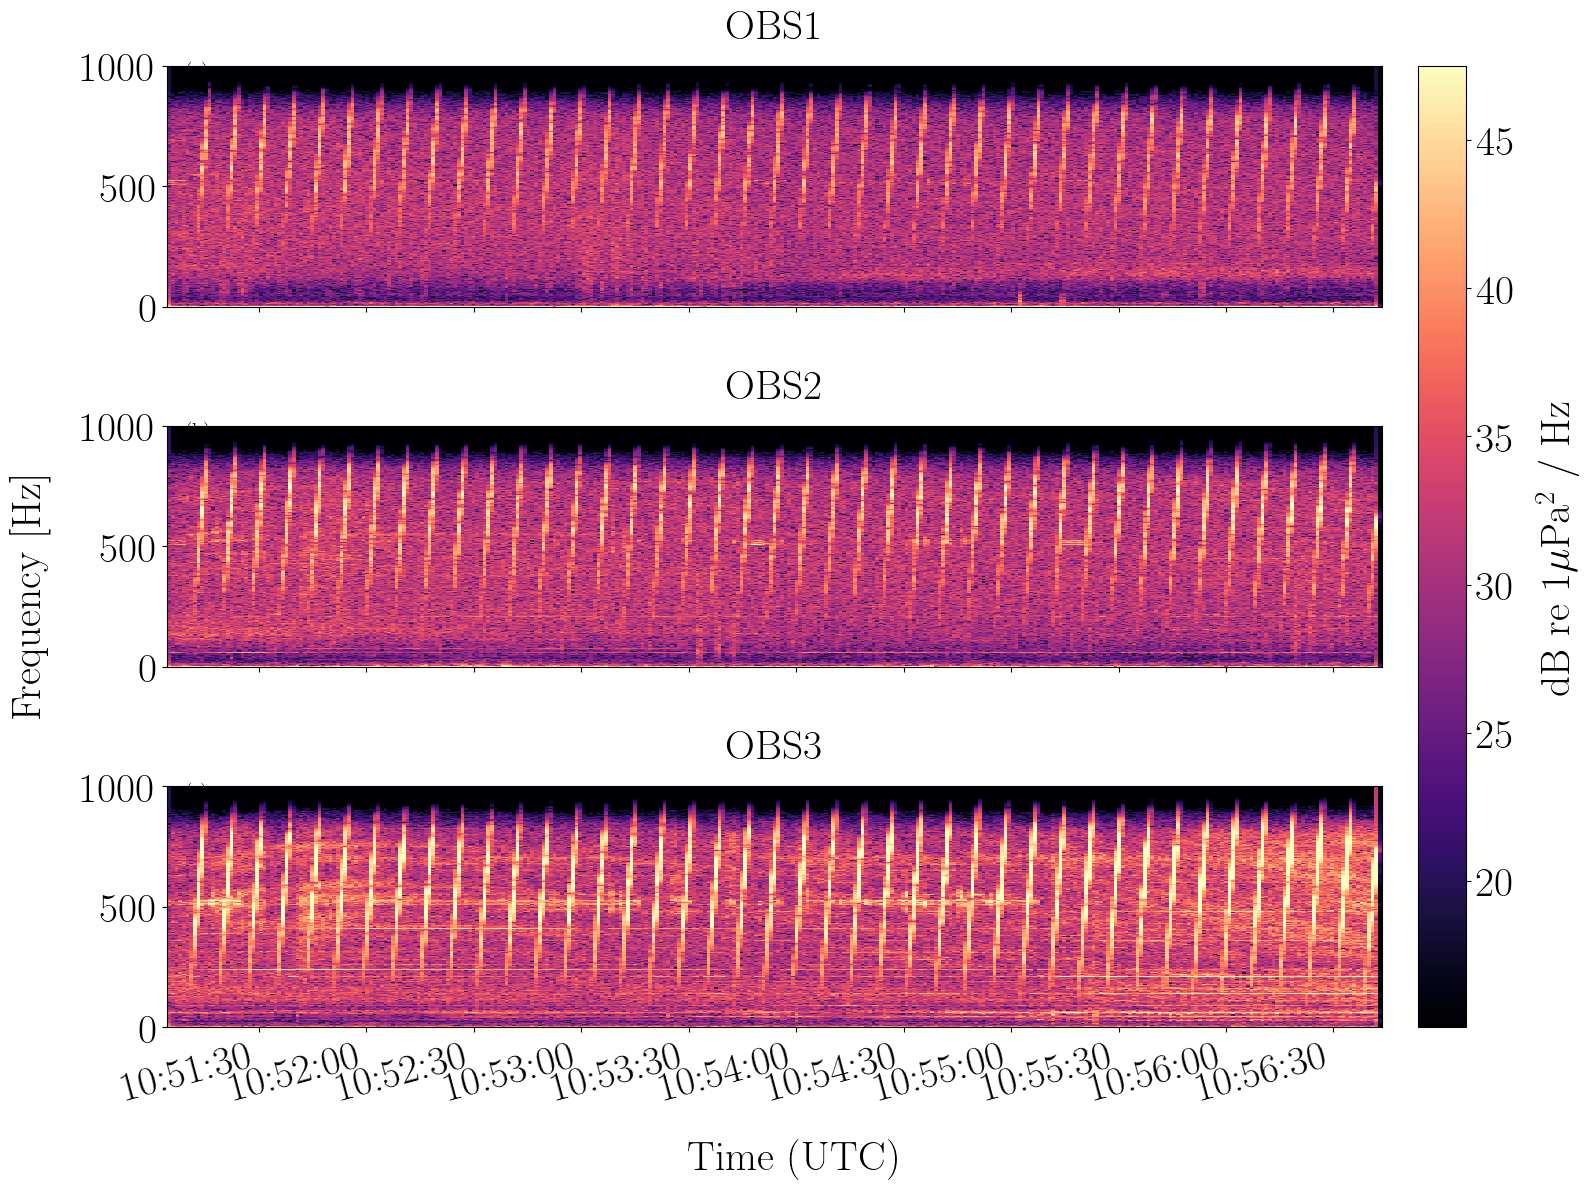

In [13]:
fmin = 0
fmax = 1000
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))


datetime_fmt = ds_sig.attrs["datetime_format"]
t_start = ds_sig.attrs[f"start_datetime"] 
sequence_start_dt = datetime.strptime(t_start, datetime_fmt)
sequence_end_dt = sequence_start_dt + timedelta(
    seconds=int(np.ceil(np.max(ds_sig.time.values)))
)

# sequence_start_dt =
# sequence_end_dt =

plot_sequence_spectrogram(
    ds_wav,
    sequence_start_dt,
    sequence_end_dt,
    savefig=False,
    fig_folder=None,
    nperseg=2**12,
    noverlap=2**11,
    fmin=fmin,
    fmax=fmax,
    # fname="spectro_3obs",
)


# Selection d'une émission 

In [14]:
pulse_id_selected = 25
df_seq_selection = df_seq.loc[df_seq["pulse_id"] == pulse_id_selected]

print(f"Signal properties for selected pulse N°{pulse_id_selected} within sequence {seq_id}:")
print(f"\tSignal type: {df_seq_selection['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq_selection['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq_selection['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq_selection['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq_selection['repeat_period_s'].iloc[0]} seconds")

Signal properties for selected pulse N°25 within sequence 144:
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds


## Position de l'émission séléctinnée

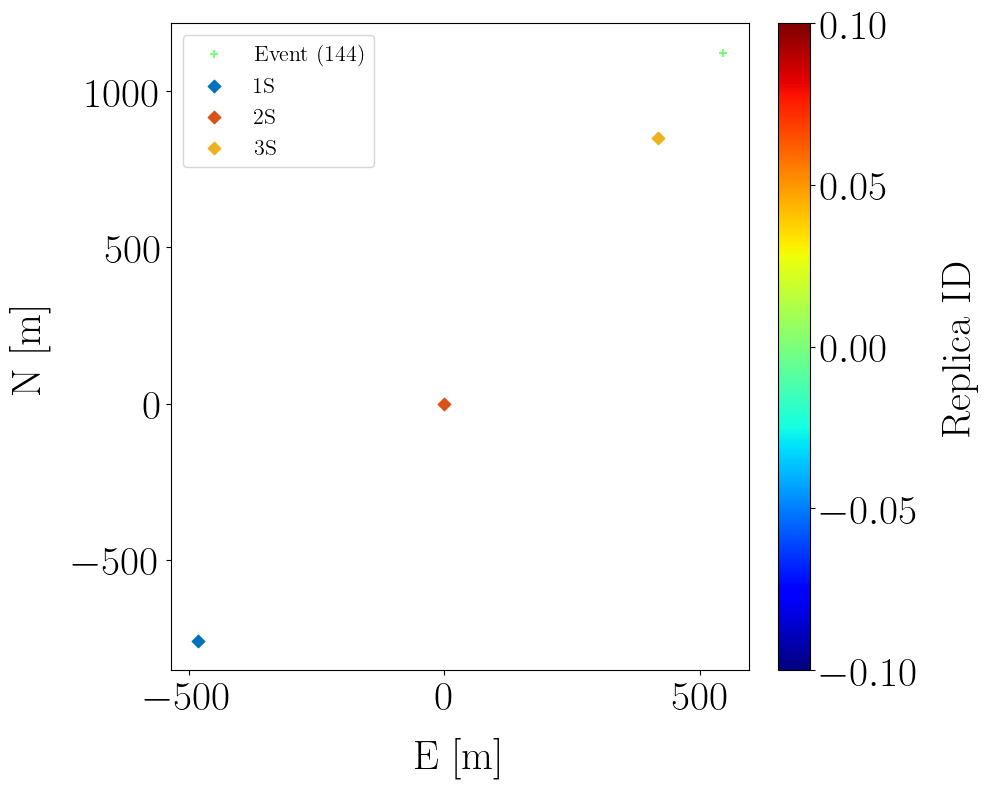

In [15]:
plot_seq_replica_positions(df_seq_selection, ds_gps, root_fig=None)

## Signal correspondant 

In [16]:
ds_sig_selection = ds_sig.sel(pulse_id=pulse_id_selected)
ds_sig_selection
# ds_sig

<xarray.Dataset> Size: 12MB
Dimensions:                     (h_index: 3, time: 672123, t_ir: 10801,
                                 f_ir: 5401, f_rtf: 8193, f_csdm: 8193,
                                 h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int64 24B 1 2 3
  * time                        (time) float32 3MB 0.0 0.0005 ... 336.1 336.1
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * f_csdm                      (f_csdm) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * h_index_bis                 (h_index_bis) int64 24B 1 2 3
    pulse_id                    int64 8B 25
Data variables:
    signal                      (h_index, time) float32 8MB ...
    arr_time_in_sec_from_start  (h_index) float32 12B ...
    ri_hat                      (h_index, t_ir) float32 130kB ...
    tf_hat_amp                  (h_index, f_ir) float32 65kB ...
    tf_hat_phase                (h_index, f_ir) float32 65kB ...
    rtf_amp_hat                 (h_index, f_rtf) float32 98kB ...
    rtf_phase_hat               (h_index, f_rtf) float32 98kB ...
    Rx                          (f_csdm, h_index, h_index_bis) float32 295kB ...
    Rv                          (f_csdm, h_index, h_index_bis) float32 295kB ...
    rtf_amp                     (h_index, f_ir) float32 65kB ...
    rtf_phase                   (h_index, f_ir) float32 65kB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        6.1754999999999995
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_10-51-05
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     10.04

In [94]:
df_seq_selection

,emission_datetime,sequence_id,src_pos_point,src_pos_status,deployed_length_m,hydrophone_distance_m,signal_type,frequency_min_hz,frequency_max_hz,duration_s,...,valid_detection_obs2,arrival_datetime_obs3,theoretical_propagation_time_obs3,measured_propagation_time_obs3,psnr_obs3,valid_detection_obs3,pulse_id,f_score_obs1,f_score_obs2,f_score_obs3
index,,,,,,,,,,,,,,,,,,,,,
778,2025-10-16 10:54:30.987218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 10:54:30.524,0.20194,-0.463218,97.649276,True,25,0.73757,0.722752,0.750788


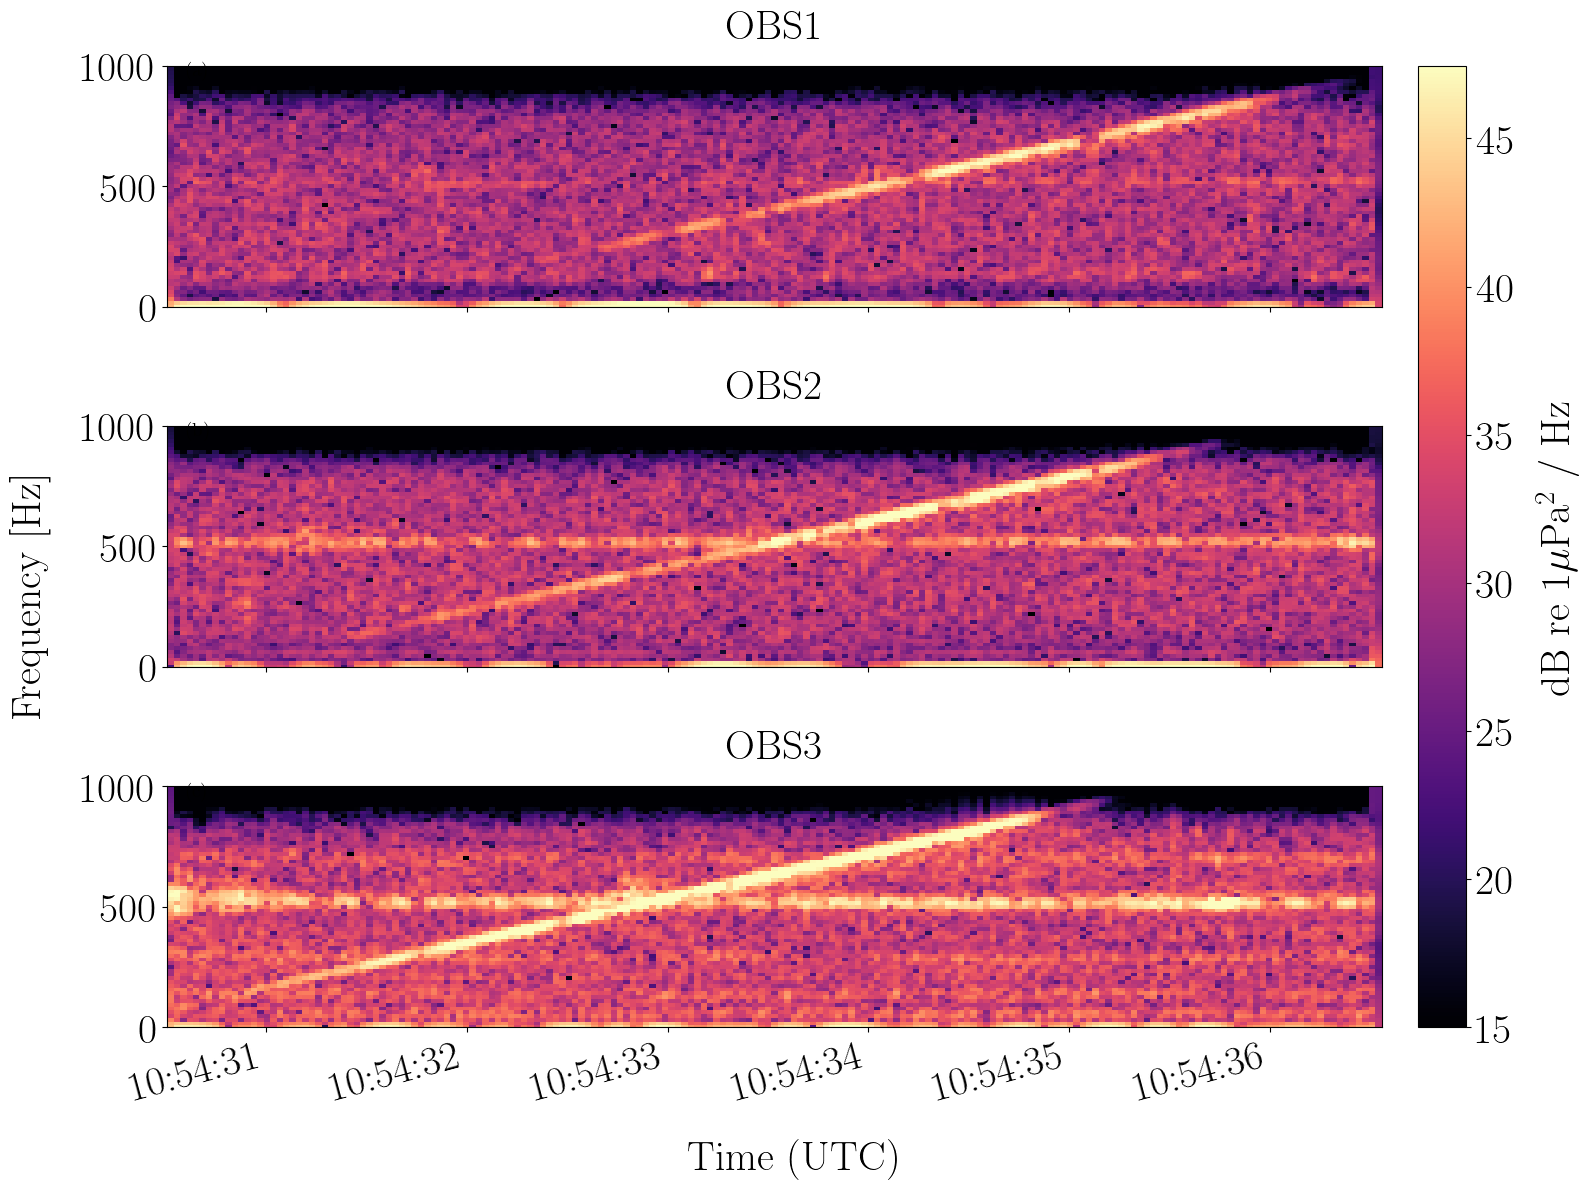

In [101]:
datetime_fmt = ds_sig.attrs["datetime_format"]
t_start = ds_sig.attrs[f"start_datetime"]

# tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.mean().item()

# sequence_start_dt = datetime.strptime(t_start, datetime_fmt) + timedelta(
#     seconds=int(np.floor(tarr_selected_pulse))
# )
# sequence_end_dt = sequence_start_dt + timedelta(
#     seconds=int(np.ceil(df_seq_selection["duration_s"].iloc[0]))
# )
sequence_start_dt = df_seq_selection["arrival_datetime_obs3"].iloc[0]
sequence_end_dt = sequence_start_dt + timedelta(
    seconds=int(np.ceil(df_seq_selection["duration_s"].iloc[0]))
)

# Add offset
# t_margin = (
#     df_seq_selection["repeat_period_s"].iloc[0] - df_seq_selection["duration_s"].iloc[0]
# )
t_margin = 1
sequence_start_dt -= timedelta(seconds=int(np.floor(t_margin * 0.5)))
sequence_end_dt += timedelta(seconds=int(np.ceil(t_margin * 0.5)))


plot_sequence_spectrogram(
    ds_wav,
    sequence_start_dt,
    sequence_end_dt,
    savefig=False,
    fig_folder=None,
    nperseg=2**7,
    noverlap=int(2**7 * 0.5),
    fmin=fmin,
    fmax=fmax,
    # fname="spectro_3obs",
)

ax = plt.gca()

# tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.sel(h_index=2).item()
# sequence_start_dt = datetime.strptime(t_start, datetime_fmt) + timedelta(
#     seconds=int(np.floor(tarr_selected_pulse))
# )
# ax.axvline(sequence_start_dt)

Text(0.02, 0.5, 'Pressure [uPa]')

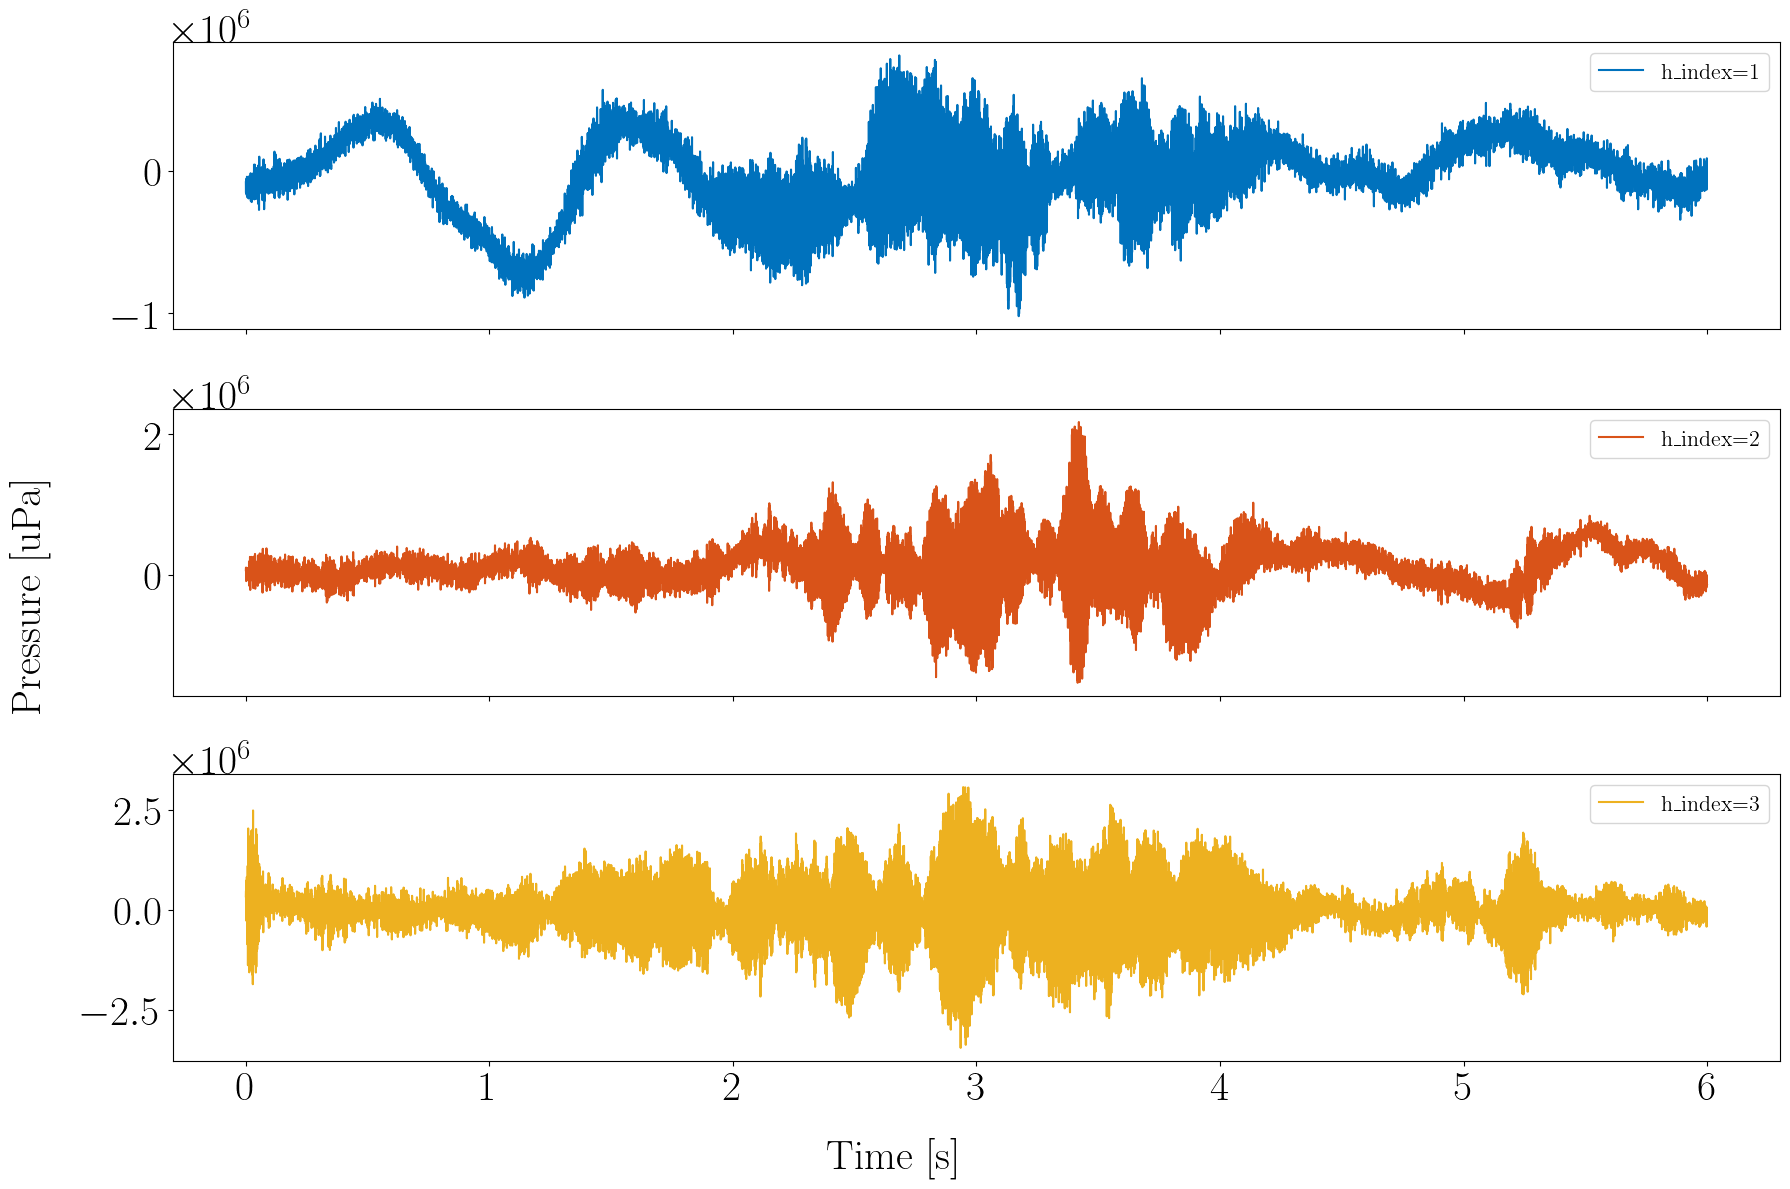

In [102]:
fig, axs = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
signals = []
# t_start_extract = []
# t_end_extract = []
for i, obs_id in enumerate([1, 2, 3]):

    datetime_fmt = ds_wav.attrs["datetime_format"]

    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    sequence_start_dt = df_seq_selection[f"arrival_datetime_obs{obs_id}"].iloc[0]
    sequence_end_dt = sequence_start_dt + timedelta(
        seconds=int(np.ceil(df_seq_selection["duration_s"].iloc[0])) + 1
    )

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (sequence_start_dt - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (sequence_end_dt - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.sel(h_index=obs_id).item()
    # dt_pulse_i = datetime.strptime(t_start, datetime_fmt) + timedelta(seconds=int(np.floor(tarr_selected_pulse)))
    # tau_pulse_i = (dt_pulse_i - sequence_start_dt).total_seconds()
    # print(tau_pulse_i)

    # t_start_extract.append(t_from_t0_start_s)
    # t_end_extract.append(t_from_t0_end_s)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})
    signals.append(sig_win.values)
    t = np.arange(len(sig_win)) / fs

    axs[i].plot(t, sig_win.values, label=f"h_index={obs_id}", color=color(i))
    axs[i].legend()

fig.supxlabel("Time [s]")
fig.supylabel("Pressure [uPa]")

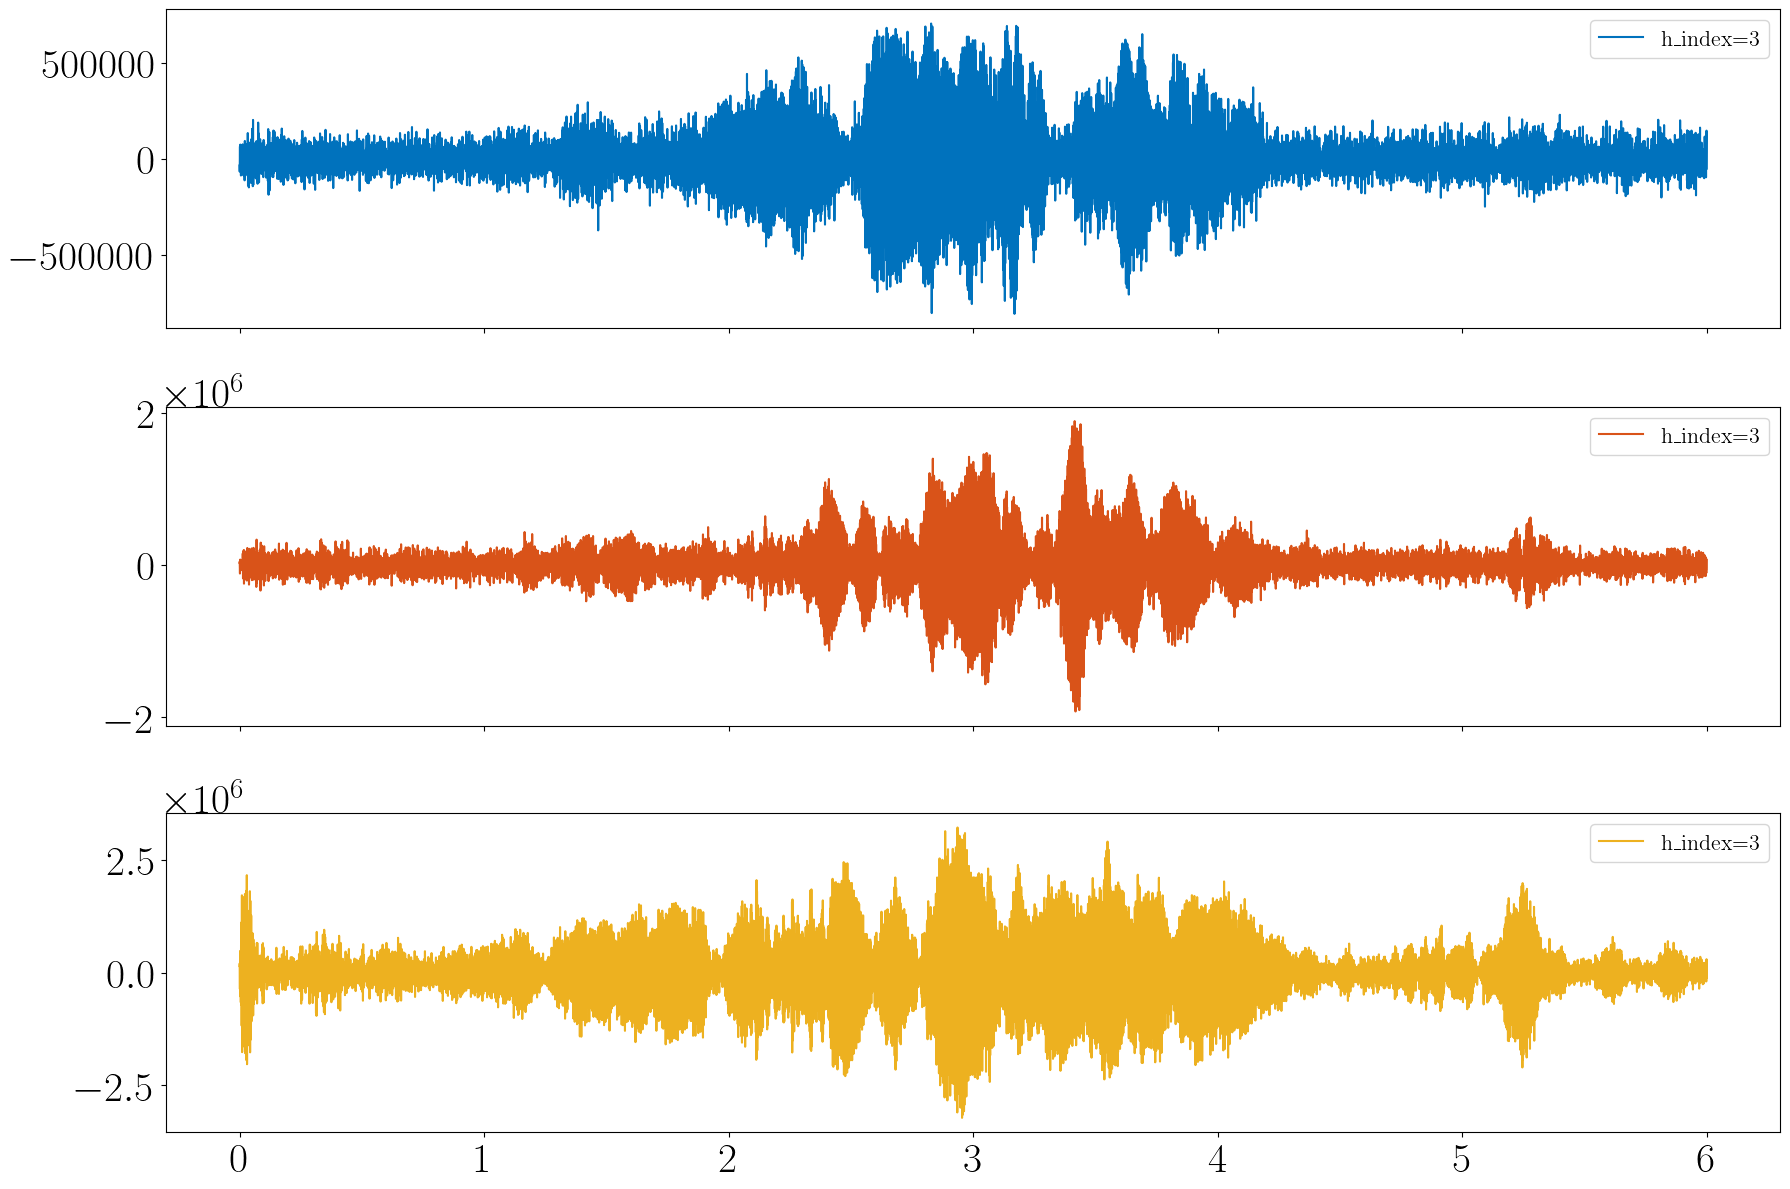

In [103]:
root_wav_save = r"C:\Users\baptiste.menetrier\Desktop\ressource\Bonnel_supp_publi_2020_warping\matlab_code\experimental_data\c_css_deconv"

bf = BandFilter(order=4, lowcut=100, highcut=900)
fs = ds_sig_selection.fs

fig, axs = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for i, h_idx in enumerate(ds_sig_selection.h_index.values):

    sig = signals[i]
    filtered_sig = bf.apply_filter(signal=sig, fs=fs)

    # tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.sel(h_index=h_idx).item()
    # t_start = tarr_selected_pulse - 0.2
    # # t_start -= t_start_extract[i]
    # t_end = tarr_selected_pulse + df_seq_selection["duration_s"].iloc[0] + 0.5
    # print(t_start)

    # sig =
    axs[i].plot(t, filtered_sig, label=f"h_index={h_idx}", color=color(i))
    axs[i].legend()

    fpath = os.path.join(
        root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}.wav"
    )
    wavfile.write(
        fpath,
        fs,
        filtered_sig,
    )

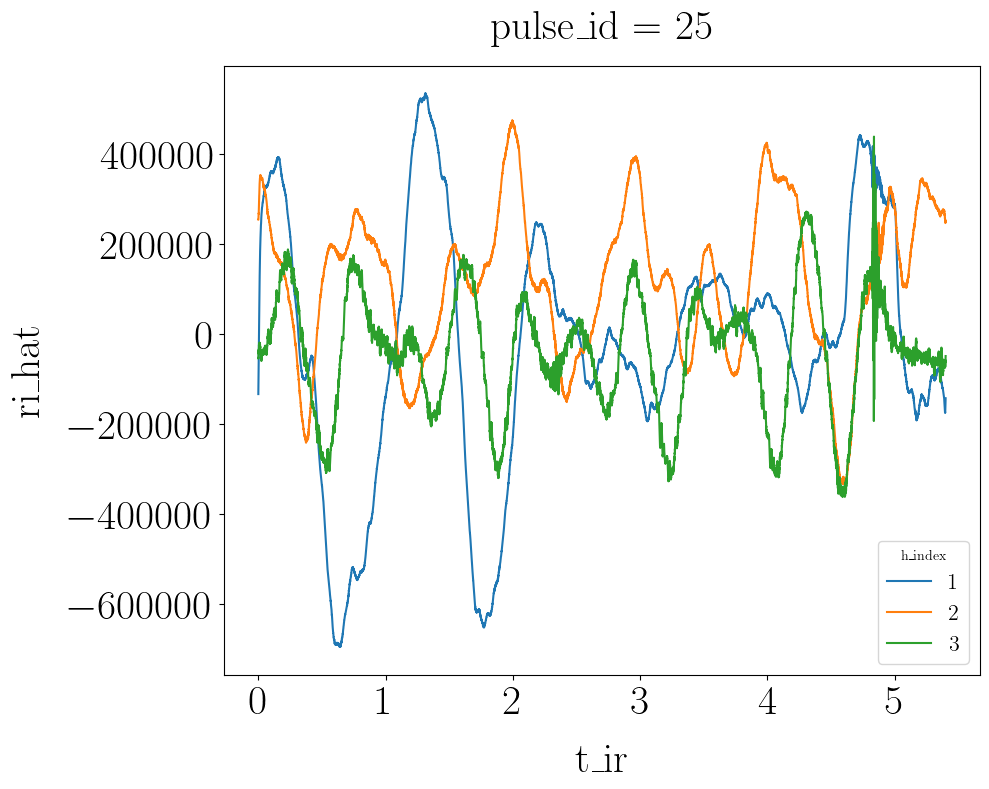

In [19]:
ds_sig_selection.ri_hat.plot(x="t_ir", hue="h_index")

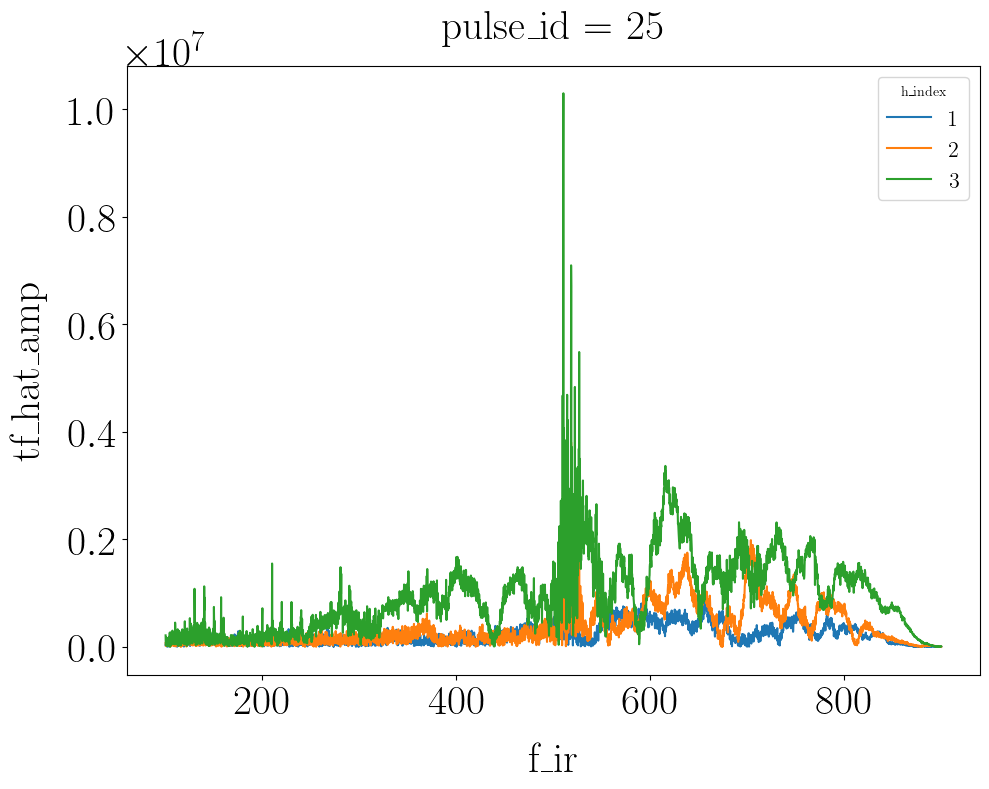

In [20]:
# ds_sig_selection.tf_hat_amp
ds_sig_selection.tf_hat_amp.sel(f_ir=slice(100, 900)).plot(x="f_ir", hue="h_index")
# ds_sig_selection

En dessous de la fréquence fmin = 80 Hz du chirp la déconvolution n'a pas de sens. Ceci conduit à des composantes basses fréquences erronées. Pour remonter à la vrai réponse impulsionnelle il faut filtrer dans la bande du signal. Ici on filtre dans la bande 100, 900 Hz pour tenir compte de la réponse de la source et de la réponse du récepteur.  

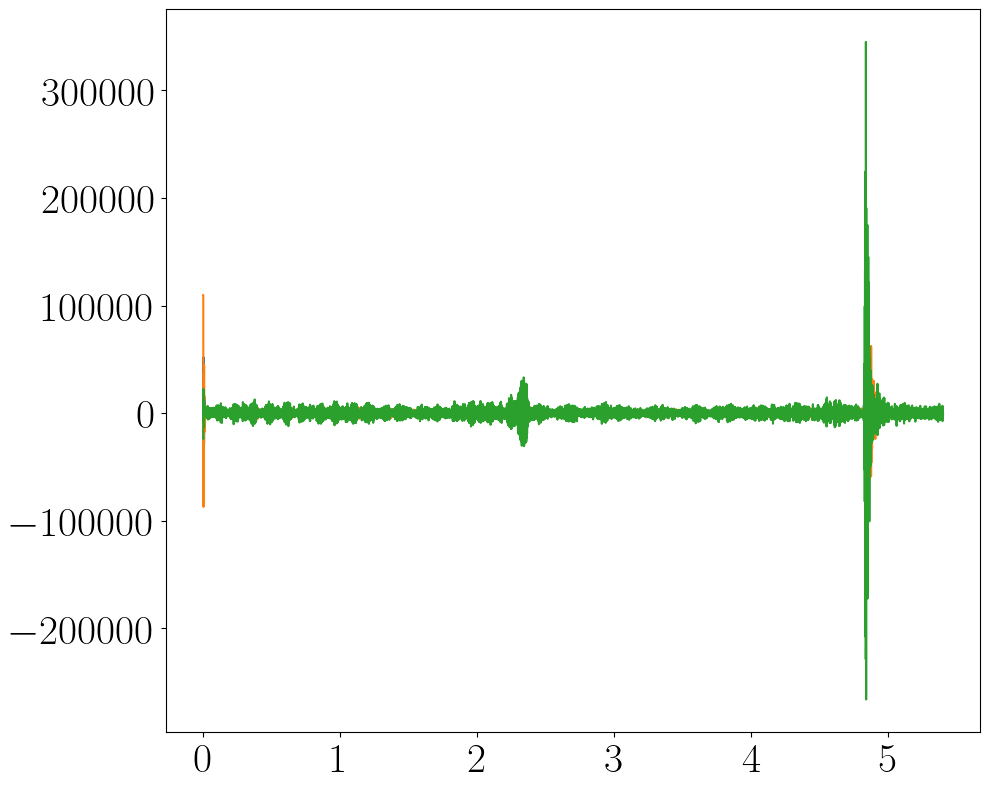

In [21]:
bf = BandFilter(order=4, lowcut=100, highcut=900)


fs = ds_sig_selection.fs

plt.figure()
impulse_responses = []
for h_idx in ds_sig_selection.h_index.values:
    ir_idx = ds_sig_selection.ri_hat.sel(h_index=h_idx).values
    filtered_ir = bf.apply_filter(signal=ir_idx, fs=fs)
    impulse_responses.append(filtered_ir)
    plt.plot(ds_sig_selection.t_ir, filtered_ir, label=f"h_index={h_idx}")

Il reste à présent à appliquer un déphasage (ou a roll) pour afficher en fonction t - r/c. En pratique trouver le bon déphasage n'est a priori pas évident, cela dépend de la fenêtre que l'on a initallement considéré pour la déconvolution. Ici on peut se contenter de tâtonner pour centrer les signaux et éviter le wrap temporel 

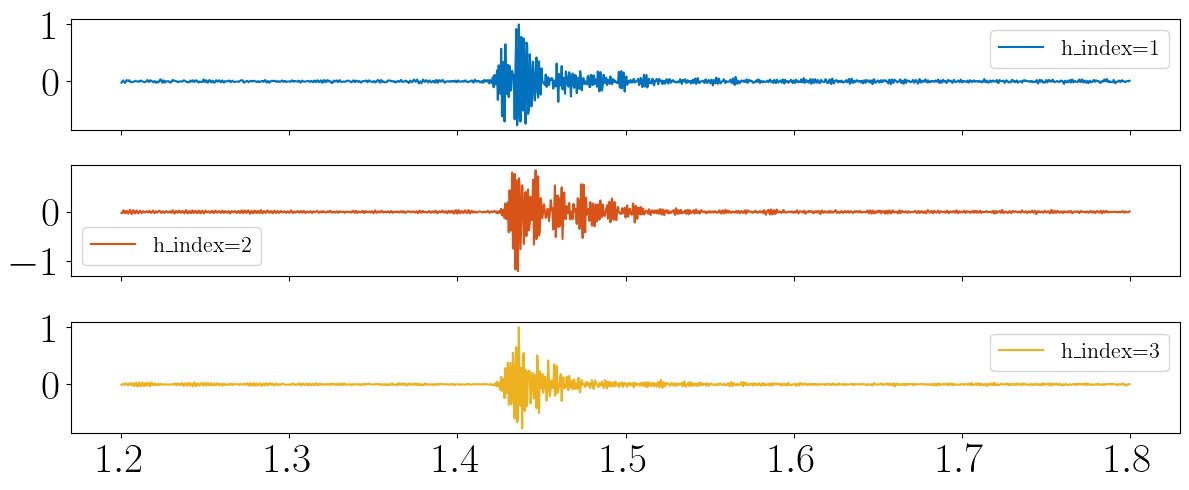

In [74]:
t_shift = 2
n_roll = int(t_shift * fs)

t_ir = ds_sig_selection.t_ir
t_win_idx = (t_ir >= 1.2) & (t_ir <= 1.8)
t_win = t_ir[t_win_idx]

fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for i, h_idx in enumerate(ds_sig_selection.h_index.values):
    rolled_ir = impulse_responses[i] / impulse_responses[i].max()
    rolled_ir = np.roll(rolled_ir, n_roll)
    rolled_ir = rolled_ir[t_win_idx]

    axs[i].plot(t_win, rolled_ir, label=f"h_index={h_idx}", color=color(i))
    axs[i].legend()

    fpath = os.path.join(
        root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}_deconv.wav"
    )
    wavfile.write(
        fpath,
        fs,
        rolled_ir,
    )



nperseg = 256, noverlap=243


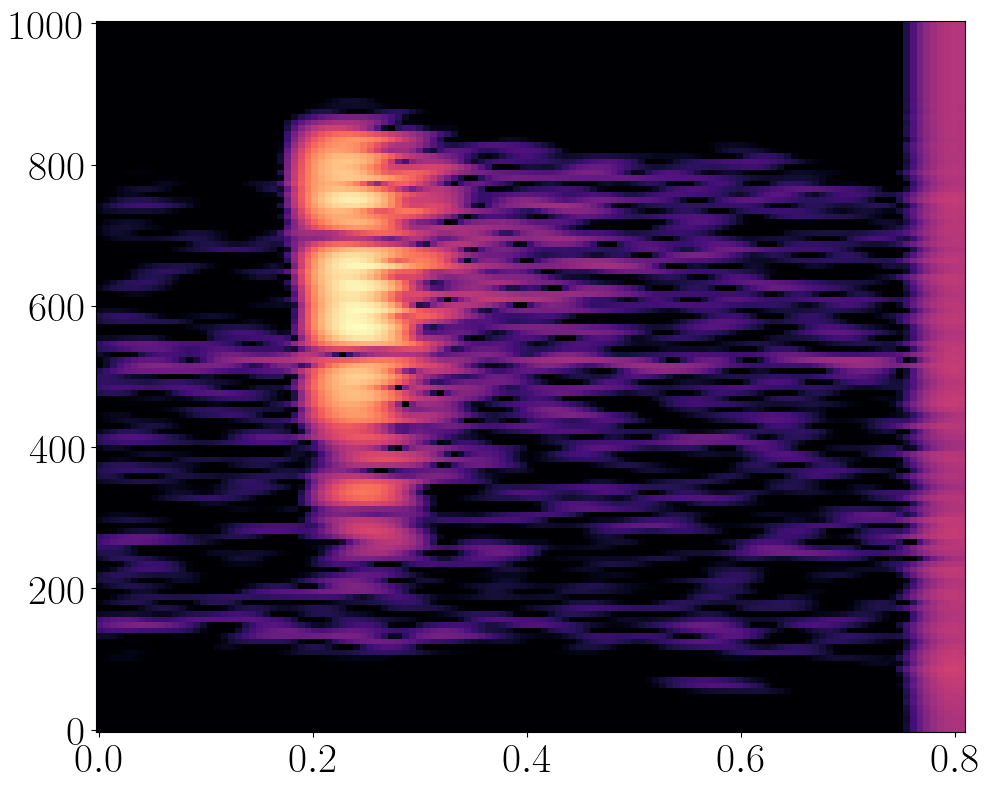

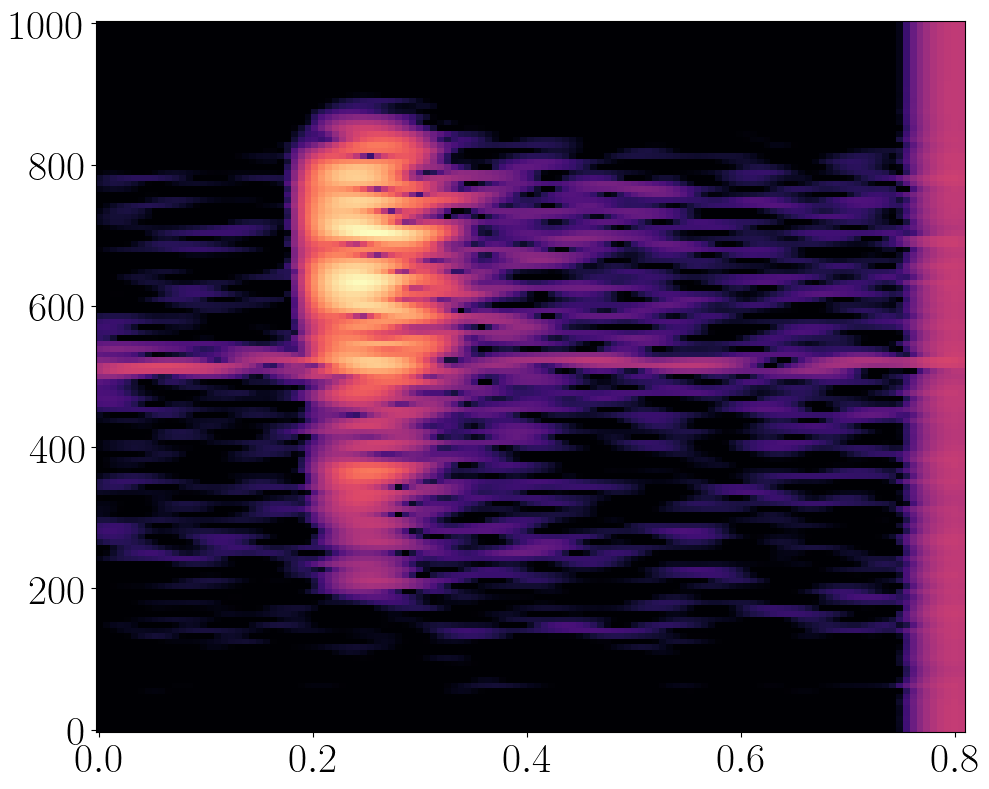

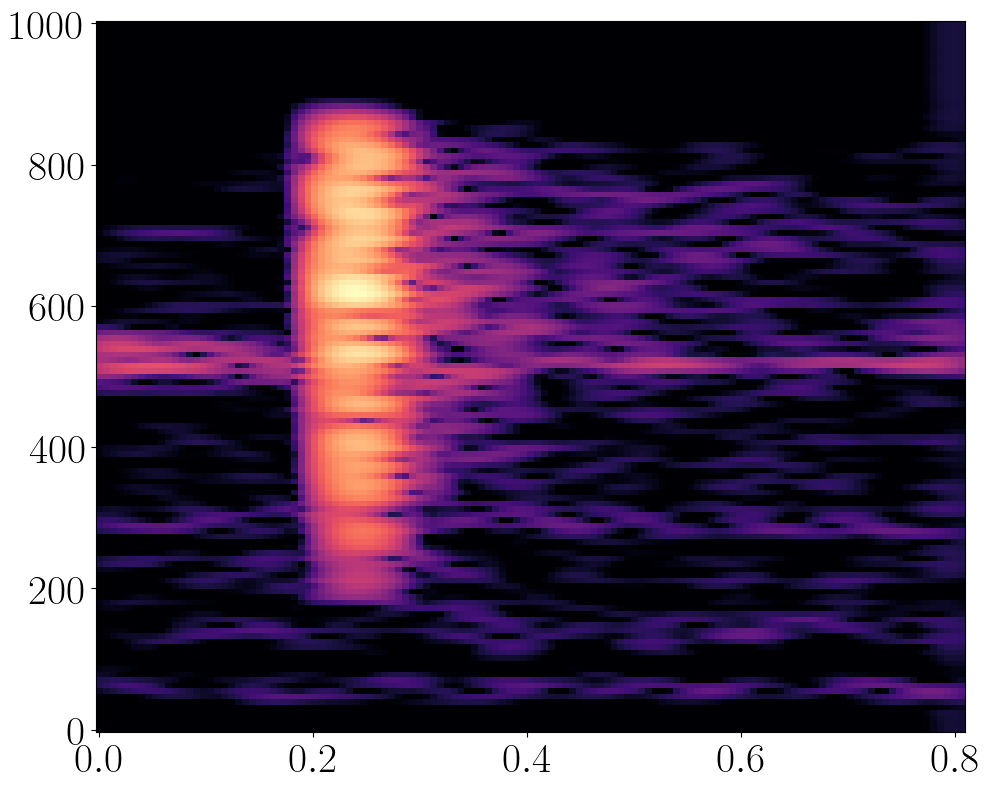

In [60]:
nperseg=2**8
# noverlap=nperseg-1
noverlap=int(nperseg*0.95)

print(f"nperseg = {nperseg}, noverlap={noverlap}")

t_ir = ds_sig_selection.t_ir
t_win_idx = (t_ir >= 1.2) & (t_ir <= 2) 
t_win = t_ir[t_win_idx]
for i, h_idx in enumerate(ds_sig_selection.h_index.values):

    rolled_ir = impulse_responses[i] / impulse_responses[i].max()
    rolled_ir = np.roll(rolled_ir, n_roll)
    rolled_ir = rolled_ir[t_win_idx]

    f, t, Sxx = sp.stft(
        rolled_ir,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  
    )
    Sxx_db= 10*np.log10(abs(Sxx))

    plt.figure()
    plt.pcolormesh(
        t,
        f,
        10*np.log10(abs(Sxx)),
        cmap="magma",
        vmin=np.percentile(Sxx_db, 40),
        vmax=np.percentile(Sxx_db, 100),
    )


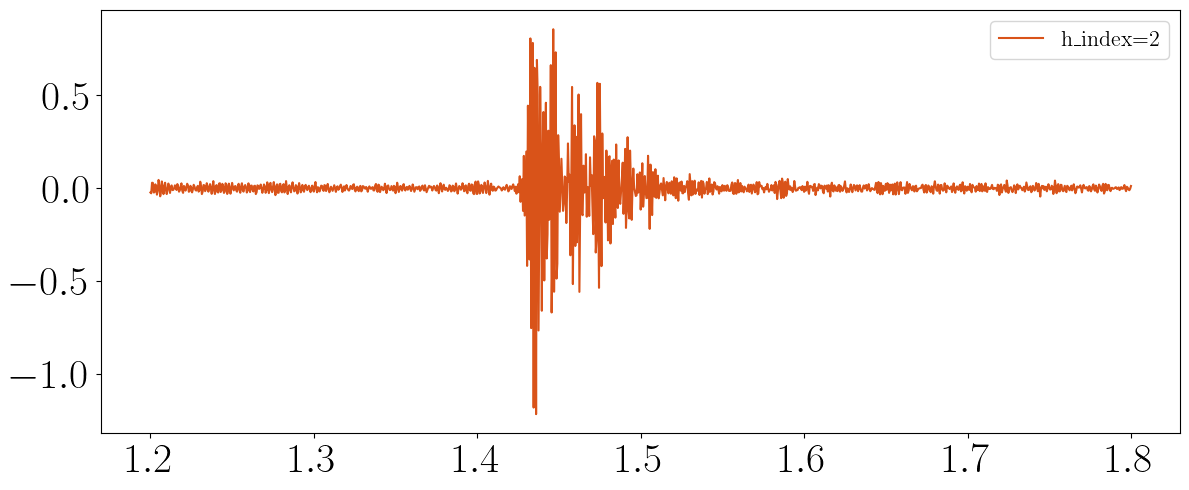

In [64]:
root_wav_save = r"C:\Users\baptiste.menetrier\Desktop\ressource\Bonnel_supp_publi_2020_warping\matlab_code\experimental_data\c_css_deconv"

t_ir = ds_sig_selection.t_ir
t_win_idx = (t_ir >= 1.2) & (t_ir <= 1.8)
t_win = t_ir[t_win_idx]

i = 1
h_idx = ds_sig_selection.h_index.values[i]

rolled_ir = impulse_responses[i] / impulse_responses[i].max()
rolled_ir = np.roll(rolled_ir, n_roll)
rolled_ir = rolled_ir[t_win_idx]

fig, axs = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
axs.plot(t_win, rolled_ir, label=f"h_index={h_idx}", color=color(i))
axs.legend()

# Save to wav
import scipy.io.wavfile as wavfile

fpath = os.path.join(root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}.wav")
wavfile.write(
    fpath,
    fs,
    rolled_ir,
)